
# Notebook 1 — Foundations of RL & Markov Decision Processes

### Course roadmap

This is notebook 1 of an 11-part series building Reinforcement Learning from first
principles, all the way up to the algorithms that train modern LLMs (RLHF, GRPO,
DPO). Every algorithm is implemented **from scratch** — only `numpy` and
`matplotlib` are used, so nothing is hidden behind a library call. Only in
notebook 10 do we switch to real libraries (PyTorch, Hugging Face `trl`) to see how
the concepts map onto production code; notebook 11 then applies everything to RLCD.

1. **Foundations & MDPs** ← *you are here*
2. Dynamic Programming (policy/value iteration)
3. Monte Carlo & Temporal-Difference Learning
4. Function Approximation & DQN
5. Policy Gradients (VPG, REINFORCE, baselines, GAE)
6. Trust Regions: Importance Sampling, KL, TRPO, PPO
7. RLHF for LLMs (SFT → Reward Model → PPO)
8. RLOO & Critic-Free Methods (RLVR)
9. GRPO & the DeepSeek-R1 line of work
10. DPO + Practical Libraries (production PyTorch/`trl` versions of DQN, PPO, RLHF, GRPO)
11. RLCD — RL from Contrastive Distillation (self-generated preference pairs)

### What this notebook covers

By the end of this notebook you will be able to:

- Explain, in your own words, why RL is a fundamentally different learning
  problem from supervised learning.
- Write down the Markov Decision Process (MDP) tuple and explain each piece.
- Derive the Bellman equation yourself, from the definition of return — not
  memorize it.
- Estimate a value function two different ways (Monte Carlo simulation, and
  exact linear algebra) and see numerically that they agree.
- See *why* generating text with an LLM is literally an MDP, and understand the
  two ways people formulate it (per-token MDP vs. per-sequence bandit) — the
  same choice that shows up later when we compare PPO to GRPO.



## 1. The big picture: what makes RL different?

Suppose you're training a model to solve grade-school math problems.

**Supervised learning** says: here is a big pile of (problem, correct solution)
pairs, collected in advance by someone else. Minimize the discrepancy between
your model's output and the labels. The data is fixed, i.i.d., and the "correct
answer" is known for every single example.

**Reinforcement learning** says something much stranger: there is no labeled
dataset at all. Instead, there is an **agent** that takes **actions**, an
**environment** that responds with a new **situation** and a **reward** signal,
and the agent's job is to figure out, purely through trial and error, which
actions lead to high reward *in the long run*.

Three properties make this hard, and all three matter enormously once we get to
LLMs:

1. **The data is not given — it is generated by the agent's own current
   behavior.** If the policy is bad, it produces bad data, and you have to
   learn from that bad data anyway. (This is why in LLM training we talk about
   "rollouts" or "generations" instead of a fixed training set.)
2. **Reward is often delayed and sparse.** You don't get told "token #47 was a
   good choice." You might only find out at the very end whether the whole
   essay was good, or whether the whole math proof was correct. This is the
   **credit assignment problem**: which of the many decisions along the way
   deserves credit (or blame) for the final outcome?
3. **There is no single "correct" action.** Many different token sequences can
   all be excellent answers. RL only asks "how good was this, relative to the
   alternatives?" — never "was this the one right answer?"

Keep this triplet — *self-generated data, delayed reward, no single correct
answer* — in your head. Every algorithm in this series is a different answer to
the question: **given only trial-and-error experience and a scalar reward
signal, how do we improve behavior?**



## 2. Formalizing the problem: the Markov Decision Process

To do math instead of vibes, we need a precise model of "agent interacting with
environment." The standard model is the **Markov Decision Process (MDP)**,
defined by a tuple:

$$
\mathcal{M} = (\mathcal{S}, \mathcal{A}, P, R, \gamma)
$$

| Symbol | Name | Meaning |
|---|---|---|
| $\mathcal{S}$ | State space | The set of all situations the agent can be in |
| $\mathcal{A}$ | Action space | The set of all moves the agent can make |
| $P(s' \mid s, a)$ | Transition function | Probability of landing in state $s'$ after taking action $a$ in state $s$ |
| $R(s, a, s')$ | Reward function | Scalar feedback received for that transition |
| $\gamma \in [0, 1]$ | Discount factor | How much we prefer reward *now* over reward *later* |

The single most important assumption baked into this model is the **Markov
property**:

$$
P(s_{t+1} \mid s_t, a_t, s_{t-1}, a_{t-1}, \dots, s_0) = P(s_{t+1} \mid s_t, a_t)
$$

In words: **the future depends only on the present state and action, not on the
full history that led there.** This is a modeling choice, not a law of nature —
its job is to make the problem tractable. Notice that we can always *force* the
Markov property to hold by stuffing enough information into the state (e.g. if
the "true" process needs memory of the past, just make the state include that
memory). We'll use exactly this trick when we get to LLMs: the "state" won't be
just the current token, it will be the *entire prompt + everything generated so
far*, which is precisely what makes token-by-token generation Markovian.

### A running example: GridWorld

To keep the ideas concrete, we'll use a tiny grid world throughout this
notebook: an agent moves on a grid, wants to reach a goal cell, and wants to
avoid a pit. This is small enough to solve exactly, which lets us sanity-check
every algorithm we implement against ground truth.


In [2]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# --- GridWorld: a minimal MDP implemented with nothing but Python/numpy ----

class GridWorld:
    """
    A rectangular grid. The agent starts at START, wants to reach GOAL
    (reward +10, episode ends), and wants to avoid PIT (reward -10, episode
    ends). Every other step costs -1, which encodes "prefer shorter paths".

    States are encoded as a single integer index 0..n_states-1 (row-major),
    which is what makes it easy to later write Bellman equations as plain
    linear algebra (a vector V of length n_states, a matrix P of shape
    (n_states, n_states)).
    """

    ACTIONS = ["up", "down", "left", "right"]
    ACTION_DELTAS = {
        "up": (-1, 0), "down": (1, 0), "left": (0, -1), "right": (0, 1),
    }

    def __init__(self, height=4, width=4, start=(0, 0), goal=(3, 3), pit=(1, 2),
                 step_reward=-1.0, goal_reward=10.0, pit_reward=-10.0, gamma=0.95):
        self.height, self.width = height, width
        self.start, self.goal, self.pit = start, goal, pit
        self.step_reward, self.goal_reward, self.pit_reward = step_reward, goal_reward, pit_reward
        self.gamma = gamma
        self.n_states = height * width
        self.n_actions = len(self.ACTIONS)

    # --- state <-> (row, col) bookkeeping ---
    def to_index(self, rc):
        r, c = rc
        return r * self.width + c

    def to_rc(self, idx):
        return divmod(idx, self.width)

    def is_terminal(self, rc):
        return rc == self.goal or rc == self.pit

    def step(self, rc, action):
        """Deterministic transition function P(s'|s,a) + reward function R."""
        if self.is_terminal(rc):
            raise ValueError("Cannot step from a terminal state — episode is over.")
        dr, dc = self.ACTION_DELTAS[action]
        r, c = rc[0] + dr, rc[1] + dc
        # walls: bumping into an edge just keeps you in place
        if not (0 <= r < self.height and 0 <= c < self.width):
            r, c = rc
        next_rc = (r, c)
        if next_rc == self.goal:
            reward = self.goal_reward
        elif next_rc == self.pit:
            reward = self.pit_reward
        else:
            reward = self.step_reward
        done = self.is_terminal(next_rc)
        return next_rc, reward, done

    def render(self, agent_rc=None):
        grid = [["." for _ in range(self.width)] for _ in range(self.height)]
        gr, gc = self.goal; pr, pc = self.pit
        grid[gr][gc] = "G"
        grid[pr][pc] = "P"
        if agent_rc is not None:
            ar, ac = agent_rc
            grid[ar][ac] = "A"
        print("\n".join(" ".join(row) for row in grid))

env = GridWorld()
print("GridWorld layout (A=agent/start, G=goal, P=pit):")
env.render(agent_rc=env.start)


GridWorld layout (A=agent/start, G=goal, P=pit):
A . . .
. . P .
. . . .
. . . G



## 3. Policies, trajectories, and return

A **policy** $\pi$ is the agent's behavior: a (possibly stochastic) mapping
from states to actions, written $\pi(a \mid s)$ — "the probability of taking
action $a$ when in state $s$." For LLMs, **the policy is literally the
language model**: $\pi_\theta(\text{next token} \mid \text{context})$ is exactly
the softmax output of the network. Keep this equivalence in mind — everything
we build about "policies" in gridworld transfers directly.

Starting from some state $s_0$ and following $\pi$, the agent generates a
**trajectory** (also called an episode or, for LLMs, a *rollout*):

$$
\tau = (s_0, a_0, r_1, s_1, a_1, r_2, s_2, \dots, s_T)
$$

The probability of a specific trajectory occurring is the product of the
policy's action probabilities and the environment's transition probabilities:

$$
P(\tau \mid \theta) = P(s_0) \prod_{t=0}^{T-1} \pi_\theta(a_t \mid s_t)\, P(s_{t+1} \mid s_t, a_t)
$$

We'll come back to this exact formula in notebook 5 — it's the starting point
for deriving the policy gradient.

### Return: turning a trajectory into a single number

RL needs one scalar number to say "how good was this trajectory." That number
is the **return**, the (discounted) sum of rewards:

$$
G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + \dots = \sum_{k=0}^{\infty} \gamma^k r_{t+1+k}
$$

**Why discount at all?** Three reasons, in order of importance for us:

1. **Mathematical convenience.** For an infinite-horizon problem, an undiscounted
   sum of rewards may not converge to a finite number. $\gamma < 1$ guarantees
   convergence (as long as rewards are bounded), because it's a geometric series.
2. **Preference for sooner reward.** All else equal, reward now is worth more
   than the same reward later (same intuition as financial discounting).
3. **Uncertainty.** The further into the future, the less certain we are that
   our model of the world (and hence our reward estimate) is accurate.

For LLM generation, episodes are *finite* by construction (a sequence ends at
an end-of-sequence token or a max-length cutoff), so reason (1) doesn't really
apply — you'll often see $\gamma = 1$ used in LLM RL. We'll return to this point
explicitly in Section 6.


In [3]:

def rollout(env, policy_fn, max_steps=50):
    """
    Simulate one full trajectory under `policy_fn`, a function
    state -> action (this is what we mean by "the policy" in code).
    Returns the list of (state, action, reward) and the final state.
    """
    s = env.start
    trajectory = []
    for _ in range(max_steps):
        a = policy_fn(s)
        s_next, r, done = env.step(s, a)
        trajectory.append((s, a, r))
        s = s_next
        if done:
            break
    return trajectory, s

def uniform_random_policy(s):
    return np.random.choice(GridWorld.ACTIONS)

def discounted_return(trajectory, gamma):
    """G_0 = sum_t gamma^t * r_{t+1}, computed directly from the definition."""
    G = 0.0
    for t, (s, a, r) in enumerate(trajectory):
        G += (gamma ** t) * r
    return G

traj, final_state = rollout(env, uniform_random_policy)
print("Sample trajectory under a UNIFORM RANDOM policy:")
for (s, a, r) in traj:
    print(f"  state={s}  action={a:<6}  reward={r:+.1f}")
print(f"Ended at {final_state} after {len(traj)} steps.")
print(f"Discounted return (gamma=0.95): {discounted_return(traj, 0.95):.3f}")


Sample trajectory under a UNIFORM RANDOM policy:
  state=(0, 0)  action=up      reward=-1.0
  state=(0, 0)  action=right   reward=-1.0
  state=(0, 1)  action=down    reward=-1.0
  state=(1, 1)  action=up      reward=-1.0
  state=(0, 1)  action=right   reward=-1.0
  state=(0, 2)  action=right   reward=-1.0
  state=(0, 3)  action=right   reward=-1.0
  state=(0, 3)  action=right   reward=-1.0
  state=(0, 3)  action=down    reward=-1.0
  state=(1, 3)  action=right   reward=-1.0
  state=(1, 3)  action=down    reward=-1.0
  state=(2, 3)  action=left    reward=-1.0
  state=(2, 2)  action=up      reward=-10.0
Ended at (1, 2) after 13 steps.
Discounted return (gamma=0.95): -14.596


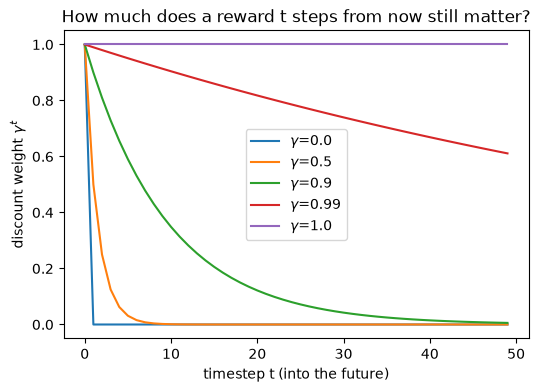

gamma=0    -> only the immediate reward matters at all (totally myopic)
gamma=1    -> a reward 50 steps away counts exactly as much as right now
gamma=0.9  -> a reward 10 steps away is already worth only ~35% of its face value


In [4]:

# Intuition builder: how does gamma change how much "the far future" matters?
# We answer this the honest way -- not by staring at the formula, but by
# plotting it -- for a trajectory that keeps collecting reward +1 forever.

gammas = [0.0, 0.5, 0.9, 0.99, 1.0]
horizon = 50
fig, ax = plt.subplots(figsize=(6, 4))
for gamma in gammas:
    weights = np.array([gamma ** t for t in range(horizon)])
    ax.plot(weights, label=f"$\\gamma$={gamma}")
ax.set_xlabel("timestep t (into the future)")
ax.set_ylabel(r"discount weight $\gamma^t$")
ax.set_title("How much does a reward t steps from now still matter?")
ax.legend()
plt.show()

print("gamma=0    -> only the immediate reward matters at all (totally myopic)")
print("gamma=1    -> a reward 50 steps away counts exactly as much as right now")
print("gamma=0.9  -> a reward 10 steps away is already worth only ~35% of its face value")



## 4. Value functions: how good is a state (or a state-action pair)?

The return $G_t$ depends on the specific random trajectory that happened to be
sampled. That's noisy. What we actually want to reason about is the *expected*
return — averaged over all the randomness in the policy and the environment.
This gives us two of the most important functions in all of RL.

**State-value function** — "how good is it to be in state $s$, if I then follow
policy $\pi$ from here on?"

$$
V^\pi(s) = \mathbb{E}_{\tau \sim \pi} \big[ G_t \mid s_t = s \big]
$$

**Action-value function (Q-function)** — "how good is it to take a *specific*
action $a$ in state $s$, and follow $\pi$ thereafter?"

$$
Q^\pi(s, a) = \mathbb{E}_{\tau \sim \pi} \big[ G_t \mid s_t = s, a_t = a \big]
$$

These two are related in a way that will matter a lot in notebook 5: $V^\pi(s)$
is just $Q^\pi(s,a)$ averaged over the actions the policy would actually take:

$$
V^\pi(s) = \sum_a \pi(a \mid s)\, Q^\pi(s, a)
$$

There's a third quantity, the **advantage function**, which we'll use
constantly starting in notebook 5, so it's worth planting the definition now:

$$
A^\pi(s, a) = Q^\pi(s, a) - V^\pi(s)
$$

Intuition: the advantage answers *"is action $a$ better or worse than what the
policy would typically do in state $s$?"* — a relative, self-correcting
measure, rather than an absolute one. Positive advantage: do more of this.
Negative: do less. This centering turns out to be exactly what makes policy
gradient methods work well in practice (much lower variance than using raw
returns) — we'll feel that pain directly in notebook 5 before fixing it.

### Estimating $V^\pi$ the "dumb but correct" way: Monte Carlo

The definition of $V^\pi(s)$ is *an expectation*. The most direct way to
estimate an expectation, if you can sample from the underlying process, is: run
many samples, average them. This is exactly what Monte Carlo estimation is —
no bootstrapping, no model of the environment required, just "try it a lot of
times and average."


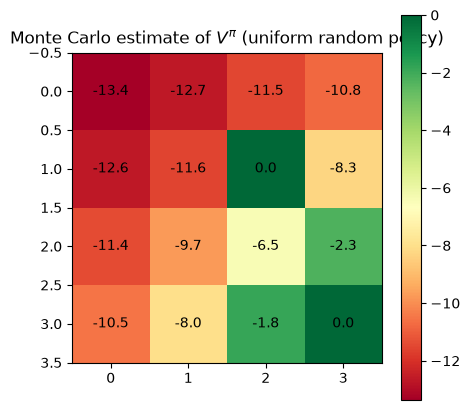

In [7]:

def estimate_V_monte_carlo(env, policy_fn, gamma, n_episodes=5000, max_steps=50):
    """
    For every state, collect the discounted return observed every time that
    state was visited across many random rollouts, then average.
    This is the most 'first principles' possible estimator of V^pi:
    it literally implements the definition V(s) = E[G_t | s_t = s].
    """
    returns_per_state = {s: [] for s in [(r, c) for r in range(env.height) for c in range(env.width)]}
    # print(returns_per_state)
    for _ in range(n_episodes):
        s0 = env.start
        
        trajectory, _  = rollout(env, policy_fn, max_steps=max_steps)
        # print(trajectory)
        # for every timestep t in this trajectory, the return-to-go from t
        # is itself a valid Monte-Carlo sample of V(s_t)
        T = len(trajectory)
        # print(T)
        # precompute returns-to-go efficiently via the recursive relationship
        # G_t = r_{t+1} + gamma * G_{t+1}  (this recursion IS next section's topic!)
        G = 0.0
        returns_to_go = [0.0] * T
        for t in reversed(range(T)):
            s, a, r = trajectory[t]
            G = r + gamma * G
            returns_to_go[t] = G
        for t in range(T):
            s, a, r = trajectory[t]
            returns_per_state[s].append(returns_to_go[t])

    V = {}
    for s, samples in returns_per_state.items():
        V[s] = np.mean(samples) if len(samples) > 0 else 0.0
    return V

V_mc = estimate_V_monte_carlo(env, uniform_random_policy, gamma=env.gamma, n_episodes=8000)

def plot_value_grid(env, V, title):
    grid = np.zeros((env.height, env.width))
    for r in range(env.height):
        for c in range(env.width):
            grid[r, c] = V.get((r, c), 0.0)
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(grid, cmap="RdYlGn")
    for r in range(env.height):
        for c in range(env.width):
            ax.text(c, r, f"{grid[r,c]:.1f}", ha="center", va="center")
    ax.set_title(title)
    plt.colorbar(im)
    plt.show()

plot_value_grid(env, V_mc, "Monte Carlo estimate of $V^\\pi$ (uniform random policy)")



Notice the pattern even before we do any more math: states closer to the pit
have *lower* value (a random policy has a real chance of wandering into it),
and states closer to the goal have *higher* value. Nothing here was
hand-coded — this pattern is entirely an emergent consequence of averaging
random rollouts. But Monte Carlo estimation has an obvious weakness: it's
**noisy** and requires *waiting until the episode ends* before you can update
anything. The next section fixes this by finding a recursive structure hiding
inside the definition of $G_t$.



## 5. The Bellman equation: recursion is the whole idea

This is the single most important derivation in this notebook — nearly every
algorithm in this course (DP, TD-learning, Q-learning, actor-critic) is a
different computational strategy for exploiting this one recursive identity.
Let's *derive* it, not quote it.

Start from the definition of return:

$$
G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + \gamma^3 r_{t+4} + \dots
$$

Factor out a single $\gamma$ from every term except the first:

$$
G_t = r_{t+1} + \gamma \underbrace{\left( r_{t+2} + \gamma r_{t+3} + \gamma^2 r_{t+4} + \dots \right)}_{\text{this is just } G_{t+1}}
$$

So we get an exact, no-approximation identity:

$$
G_t = r_{t+1} + \gamma\, G_{t+1}
$$

**The return at time $t$ equals the immediate reward, plus the discounted
return from time $t+1$ onward.** That's it — that's the entire idea. Now take
expectations of both sides (recall $V^\pi(s) = \mathbb{E}[G_t \mid s_t = s]$):

$$
V^\pi(s) = \mathbb{E}_{a \sim \pi,\, s' \sim P} \Big[ r(s,a,s') + \gamma\, V^\pi(s') \Big]
$$

Written out as an explicit sum over actions and next-states, this is the
**Bellman expectation equation**:

$$
V^\pi(s) = \sum_{a} \pi(a \mid s) \sum_{s'} P(s' \mid s, a) \Big[ R(s,a,s') + \gamma V^\pi(s') \Big]
$$

The same trick applied to $Q^\pi$ gives:

$$
Q^\pi(s, a) = \sum_{s'} P(s' \mid s, a) \Big[ R(s,a,s') + \gamma \sum_{a'} \pi(a' \mid s')\, Q^\pi(s', a') \Big]
$$

**Why this matters so much:** $V^\pi$ is defined in terms of *itself*. This
turns "compute an expectation over infinitely many future trajectories" into
"solve a system of equations that only ever looks one step ahead." That's an
enormous simplification, and it's the reason RL algorithms can be incremental
(update from one step of experience) rather than needing to see full episodes.

### The Bellman *optimality* equation

Everything so far was "how good is this state, under this *particular*
policy $\pi$." But what we actually want is the *best possible* policy. Define
the optimal value functions as the value achieved by the best possible policy:

$$
V^*(s) = \max_\pi V^\pi(s), \qquad Q^*(s,a) = \max_\pi Q^\pi(s,a)
$$

A key fact (which we'll use without full proof, but the intuition is below):
the optimal policy is *greedy* with respect to $Q^*$ — i.e. once you know
$Q^*$, the best action is simply $\arg\max_a Q^*(s,a)$. Substituting "always
pick the best action" in place of "average over $\pi$" in the Bellman
expectation equation gives the **Bellman optimality equation**:

$$
V^*(s) = \max_a \sum_{s'} P(s' \mid s, a) \Big[ R(s,a,s') + \gamma V^*(s') \Big]
$$

**Intuition for why the max is in the right place:** $V^*(s)$ asks "what's the
best possible long-run outcome from $s$?" The best long-run outcome is: pick
whichever *single* action right now leads to the best combination of
(immediate reward + optimal value from wherever you land). You don't average
over actions anymore, because you're not committed to any fixed policy — you
get to *choose* the best one at every state. This equation is nonlinear (because
of the max), which is precisely why solving it needs the iterative algorithms
of notebook 2 (value iteration / policy iteration), rather than the direct
linear-algebra trick we're about to use for the *expectation* equation.



### Solving the Bellman expectation equation exactly, with linear algebra

For our fixed random policy $\pi$ and a small, finite state space, the Bellman
expectation equation is actually just a **linear system** in disguise. Define:

- $V \in \mathbb{R}^{n}$ — the vector of values for all $n$ states
- $R^\pi \in \mathbb{R}^n$ — the expected immediate reward from each state under $\pi$
- $P^\pi \in \mathbb{R}^{n \times n}$ — the state-to-state transition matrix induced by $\pi$, i.e. $P^\pi_{s,s'} = \sum_a \pi(a|s) P(s'|s,a)$

Then the Bellman expectation equation for *all states simultaneously* is:

$$
V = R^\pi + \gamma P^\pi V \quad\Longrightarrow\quad (I - \gamma P^\pi) V = R^\pi \quad\Longrightarrow\quad V = (I - \gamma P^\pi)^{-1} R^\pi
$$

This is an **exact, closed-form solution** — no simulation, no noise, no
iteration. It only works because the state space is small enough to build the
matrix explicitly (real problems can't do this — that's *why* the rest of this
course exists). But for our GridWorld, it gives us ground truth we can check
every future algorithm against. Terminal states need special handling: once you
reach the goal or pit, the episode is over, so their "future value" is defined
to be exactly 0 (there is no next state to bootstrap from).


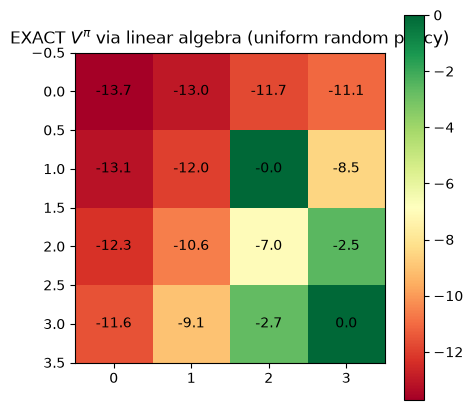

In [5]:

def build_bellman_system(env, policy_probs):
    """
    policy_probs: dict state -> dict action -> probability, i.e. pi(a|s).
    Builds P^pi (n x n) and R^pi (n,) so we can solve V = (I - gamma P)^-1 R.
    Terminal states are made absorbing with zero reward, which correctly
    encodes 'the episode has ended, no more future value accrues'.
    """
    n = env.n_states
    P_pi = np.zeros((n, n))
    R_pi = np.zeros(n)

    for r in range(env.height):
        for c in range(env.width):
            s = (r, c)
            idx = env.to_index(s)
            if env.is_terminal(s):
                P_pi[idx, idx] = 1.0   # stays put forever, absorbing
                R_pi[idx] = 0.0
                continue
            for a, p_a in policy_probs[s].items():
                if p_a == 0.0:
                    continue
                s_next, reward, _ = env.step(s, a)
                idx_next = env.to_index(s_next)
                P_pi[idx, idx_next] += p_a
                R_pi[idx] += p_a * reward
    return P_pi, R_pi

# uniform random policy, expressed explicitly as pi(a|s)
uniform_probs = {
    (r, c): {a: 0.25 for a in GridWorld.ACTIONS}
    for r in range(env.height) for c in range(env.width)
}

P_pi, R_pi = build_bellman_system(env, uniform_probs)
I = np.eye(env.n_states)
V_exact_vec = np.linalg.solve(I - env.gamma * P_pi, R_pi)
V_exact = {env.to_rc(i): V_exact_vec[i] for i in range(env.n_states)}

plot_value_grid(env, V_exact, "EXACT $V^\\pi$ via linear algebra (uniform random policy)")


In [6]:

# Sanity check: does noisy Monte-Carlo simulation actually converge to the
# exact linear-algebra answer? This is the moment where the abstract "V^pi(s)
# = E[G_t | s_t=s]" and the recursive Bellman equation get tied together
# empirically -- two totally different computational routes, same target.

print(f"{'state':>8}  {'Monte Carlo':>12}  {'Exact (Bellman)':>16}  {'abs diff':>9}")
for r in range(env.height):
    for c in range(env.width):
        s = (r, c)
        mc, ex = V_mc[s], V_exact[s]
        print(f"{str(s):>8}  {mc:12.3f}  {ex:16.3f}  {abs(mc-ex):9.3f}")

errors = [abs(V_mc[s] - V_exact[s]) for s in V_exact]
print(f"\nMean absolute error (Monte Carlo vs. exact): {np.mean(errors):.4f}")
print("Small, nonzero, and shrinks as n_episodes grows -- exactly what we'd expect")
print("from an unbiased but noisy estimator of the same underlying quantity.")


   state   Monte Carlo   Exact (Bellman)   abs diff
  (0, 0)       -13.414           -13.717      0.303
  (0, 1)       -12.624           -12.969      0.345
  (0, 2)       -11.485           -11.748      0.263
  (0, 3)       -10.748           -11.063      0.315
  (1, 0)       -12.656           -13.142      0.486
  (1, 1)       -11.522           -11.963      0.441
  (1, 2)         0.000            -0.000      0.000
  (1, 3)        -8.107            -8.498      0.390
  (2, 0)       -11.549           -12.301      0.752
  (2, 1)        -9.974           -10.576      0.602
  (2, 2)        -6.570            -7.006      0.436
  (2, 3)        -2.205            -2.534      0.329
  (3, 0)       -10.533           -11.564      1.031
  (3, 1)        -8.332            -9.050      0.718
  (3, 2)        -2.447            -2.706      0.260
  (3, 3)         0.000             0.000      0.000

Mean absolute error (Monte Carlo vs. exact): 0.4168
Small, nonzero, and shrinks as n_episodes grows -- exactly what


## 6. From grids to language models: text generation *is* an MDP

Here's the payoff for all the formalism above. Take an autoregressive language
model generating a response to a prompt, one token at a time. Map it onto the
MDP tuple:

| MDP component | GridWorld | LLM generation |
|---|---|---|
| State $s_t$ | agent's (row, col) | prompt + all tokens generated so far |
| Action $a_t$ | {up, down, left, right} | next token, chosen from the vocabulary |
| Transition $P(s'\mid s,a)$ | deterministic move | **deterministic**: append the chosen token to the context |
| Policy $\pi_\theta(a\mid s)$ | lookup table / rule | the LLM's softmax distribution over the vocabulary |
| Reward $R$ | −1/step, ±10 terminal | depends on the setup — see below |
| Episode end | reach goal or pit | an end-of-sequence token is generated, or a max length is hit |

Two things are worth pausing on, because they come back explicitly when we
compare PPO to GRPO in notebooks 6–9.

**1. The transition function is trivially deterministic.** Given the current
context and the chosen token, there is *no uncertainty whatsoever* about the
next state — it's just string concatenation. All the "hard" randomness in LLM
RL lives entirely in the *policy* (which token to sample), not in the
environment dynamics. This is unusual compared to most classic RL problems
(robotics, games) where the environment itself is stochastic or adversarial.

**2. Where does the reward actually come from, and when?** In most LLM RL
setups, there is a *single* reward for the entire completion, delivered only at
the very end (e.g. a reward model scores the finished response; a math grader
checks the final answer). Every intermediate token gets reward $0$. This is
about as sparse and delayed as credit assignment gets — and it directly
motivates two different ways people choose to *formulate* the problem:

- **The MDP (per-token) formulation** treats each generated token as its own
  action with its own state. Even though reward only arrives at the end, you
  can still define a per-token value function $V(s_t)$ (how good is the partial
  generation so far?) and get partial credit assignment via the Bellman
  recursion — exactly the machinery of this notebook. This is what PPO for
  LLMs does (notebook 7).
- **The Bandit (whole-sequence) formulation** instead treats generating the
  *entire completion* as a single action, taken from a single "state" (the
  prompt). There's no intra-sequence recursion at all — just one action, one
  reward, full stop. This is simpler, and it's the view taken by REINFORCE,
  RLOO, and GRPO (notebooks 5, 8, 9).

Neither formulation is "more correct" — they're different modeling choices with
different bias/variance and compute trade-offs, and a running theme for the
rest of this course is watching how that choice ripples through every
algorithm we build.

### Making it concrete: a tiny "token MDP"

We don't need an actual neural network to *feel* this. Below, we reuse the
exact same `rollout` and value-estimation code from this notebook, just pointed
at a miniature sequence-generation environment: a vocabulary of 3 symbols, a
max length of 3, and a reward that is delivered only at the end.


In [7]:

class TinySequenceEnv:
    """
    A minimal stand-in for 'an LLM generating tokens'. Vocabulary = {A, B, C}.
    State = the sequence generated so far (a tuple of tokens). An episode ends
    when the sequence has length `max_len`. Reward is 0 for every token except
    the very last one, where the agent is rewarded for matching a target
    pattern -- deliberately sparse and terminal-only, just like RLHF/RLVR.
    """
    ACTIONS = ["A", "B", "C"]

    def __init__(self, target=("A", "B", "C"), max_len=3):
        self.target = target
        self.max_len = max_len
        self.start = tuple()   # empty context = start of generation
        self.gamma = 1.0       # episodes are finite -> no need to discount

    def is_terminal(self, s):
        return len(s) >= self.max_len

    def step(self, s, a):
        s_next = s + (a,)
        done = self.is_terminal(s_next)
        if done:
            reward = 1.0 if s_next == self.target else 0.0
        else:
            reward = 0.0
        return s_next, reward, done


def make_uniform_token_policy(actions):
    return lambda s: np.random.choice(actions)


seq_env = TinySequenceEnv()
policy = make_uniform_token_policy(TinySequenceEnv.ACTIONS)

def seq_rollout(env, policy_fn):
    s = env.start
    trajectory = []
    while not env.is_terminal(s):
        a = policy_fn(s)
        s_next, r, done = env.step(s, a)
        trajectory.append((s, a, r))
        s = s_next
    return trajectory

print("Three sample 'generations' under a uniform random token policy:")
for _ in range(3):
    traj = seq_rollout(seq_env, policy)
    seq = "".join(a for (_, a, _) in traj)
    total_reward = sum(r for (_, _, r) in traj)
    print(f"  generated='{seq}'   terminal reward={total_reward}")

# Monte-Carlo estimate of V(s) for every *prefix* state, exactly the same
# estimator we wrote for GridWorld -- reward only shows up at the leaves,
# so V(prefix) is literally 'probability of completing the target from here'
# under a uniform-random continuation policy.
from collections import defaultdict
returns_per_prefix = defaultdict(list)
n_episodes = 20000
for _ in range(n_episodes):
    traj = seq_rollout(seq_env, policy)
    G = 0.0
    T = len(traj)
    returns_to_go = [0.0] * T
    for t in reversed(range(T)):
        s, a, r = traj[t]
        G = r + seq_env.gamma * G
        returns_to_go[t] = G
    prefix = seq_env.start
    returns_per_prefix[prefix].append(returns_to_go[0])
    for t in range(T):
        s, a, r = traj[t]
        next_prefix = s + (a,)
        if t + 1 < T:
            returns_per_prefix[next_prefix].append(returns_to_go[t + 1])

def theoretical_V(prefix, target):
    """V(prefix) = P(uniform-random continuation completes to `target`).
    Zero the moment the prefix has already diverged from the target."""
    if prefix != target[:len(prefix)]:
        return 0.0
    return 1 / 3 ** (len(target) - len(prefix))

print("\nEstimated V(prefix) = P(reach target 'ABC' | uniform random continuation):")
for prefix in sorted(returns_per_prefix, key=lambda p: (len(p), p)):
    vals = returns_per_prefix[prefix]
    label = "".join(prefix) if prefix else "<empty prompt>"
    theo = theoretical_V(prefix, seq_env.target)
    print(f"  V({label!r:12}) ~= {np.mean(vals):.4f}   (theoretical: {theo:.4f})")


Three sample 'generations' under a uniform random token policy:
  generated='BBC'   terminal reward=0.0
  generated='BCA'   terminal reward=0.0
  generated='ACB'   terminal reward=0.0



Estimated V(prefix) = P(reach target 'ABC' | uniform random continuation):
  V('<empty prompt>') ~= 0.0355   (theoretical: 0.0370)
  V('A'         ) ~= 0.1083   (theoretical: 0.1111)
  V('B'         ) ~= 0.0000   (theoretical: 0.0000)
  V('C'         ) ~= 0.0000   (theoretical: 0.0000)
  V('AA'        ) ~= 0.0000   (theoretical: 0.0000)
  V('AB'        ) ~= 0.3220   (theoretical: 0.3333)
  V('AC'        ) ~= 0.0000   (theoretical: 0.0000)
  V('BA'        ) ~= 0.0000   (theoretical: 0.0000)
  V('BB'        ) ~= 0.0000   (theoretical: 0.0000)
  V('BC'        ) ~= 0.0000   (theoretical: 0.0000)
  V('CA'        ) ~= 0.0000   (theoretical: 0.0000)
  V('CB'        ) ~= 0.0000   (theoretical: 0.0000)
  V('CC'        ) ~= 0.0000   (theoretical: 0.0000)



Look at the pattern: $V(\text{empty prompt}) \approx 1/27$, $V(\text{"A"})
\approx 1/9$, $V(\text{"AB"}) \approx 1/3$, and once the full sequence "ABC" is
generated the reward is already realized. **The value function is doing
partial credit assignment for us** — even though the *environment* only ever
hands out a reward at the very last token, the recursive Bellman structure lets
us assign a sensible "how promising is this prefix" score to every intermediate
state, purely by propagating the terminal reward backward through the
recursion $G_t = r_{t+1} + \gamma G_{t+1}$. This is the seed of the entire
actor-critic idea we'll build properly in notebooks 5–7: **a learned value
function turns sparse, delayed, end-of-sequence rewards into dense,
step-by-step training signal.**



## 7. Recap, and what's next

**What we derived, from first principles, in this notebook:**

- RL's defining trait: the agent generates its own data, reward is delayed and
  sparse, and there is no single correct action — only "better vs. worse."
- The MDP formalism $(\mathcal{S}, \mathcal{A}, P, R, \gamma)$ and the Markov
  property, which is a modeling choice enforced by what you put in the state.
- Trajectories, and return $G_t = \sum_k \gamma^k r_{t+1+k}$, with an honest
  account of *why* we discount.
- $V^\pi(s)$ and $Q^\pi(s,a)$ as expectations over return, and the advantage
  $A^\pi(s,a) = Q^\pi(s,a) - V^\pi(s)$ as a *relative* goodness measure.
- The **Bellman equation**, derived (not quoted!) from the one-line identity
  $G_t = r_{t+1} + \gamma G_{t+1}$ — the recursive idea every later algorithm
  exploits in a different way.
- Two independent ways to compute $V^\pi$ — noisy Monte Carlo simulation, and
  exact linear algebra — and verified numerically that they agree.
- The MDP-vs-Bandit framing of LLM generation, and a concrete toy example
  showing how a value function propagates a single sparse terminal reward
  backward into dense per-prefix training signal.

**The gap we deliberately left open:** we can *evaluate* a fixed policy's value
function (both by simulation and exactly), but we have no way yet to *improve*
the policy — to find a better one than "uniform random." That's exactly the
subject of **Notebook 2: Dynamic Programming**, where the Bellman
*optimality* equation (Section 5) stops being just a nice identity and becomes
an actual algorithm — policy iteration and value iteration — for computing the
optimal policy exactly, still in our small GridWorld, still without any
learning-rate/gradient machinery at all.

### Exercises (optional, but where the intuition really sinks in)

1. Change `gamma` to `0.0` and re-run the value estimation. Does the resulting
   $V^\pi$ match your intuition for "totally myopic agent"?
2. Add a second pit to GridWorld. Does the value heatmap change the way you'd
   expect?
3. Make the environment **stochastic**: with probability 0.1, an action moves
   the agent in a random direction instead of the intended one (like "wind").
   Update `P_pi` accordingly and re-solve — does $V^\pi$ decrease everywhere,
   and does it decrease *more* near the pit? Why?
4. In `TinySequenceEnv`, change the reward so that *any* sequence containing
   "B" anywhere (not just matching the full target) gets partial reward 0.5.
   Re-run the value estimation — how does this change the values of prefixes
   that already contain a "B"? This is a hand-built miniature of a **process
   reward** vs. the pure **outcome reward** we started with — a distinction we
   revisit in notebook 7.
